<a href="https://colab.research.google.com/github/utsho261/Student-Performance-Data-Mining-Project/blob/main/Student_Performance_Data_Mining_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PART 0: Setup — Google Drive Mount & Library Import

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style="whitegrid")

print("All libraries imported successfully!")
print("Google Drive mounted successfully!")

Mounted at /content/drive
All libraries imported successfully!
Google Drive mounted successfully!


PART 1: Data Loading

In [2]:
DS1_PATH = '/content/drive/MyDrive/Data Mining Lab/StudentsPerformance.csv'
DS2_PATH = '/content/drive/MyDrive/Data Mining Lab/StudentPerformanceFactors.csv'

df1 = pd.read_csv(DS1_PATH)
df2 = pd.read_csv(DS2_PATH)

print("=" * 60)
print("DATASET 1 — StudentsPerformance.csv")
print("=" * 60)
print(f"Shape: {df1.shape}  ({df1.shape[0]} rows, {df1.shape[1]} columns)")
print("\nColumns:", df1.columns.tolist())
print("\nFirst 5 rows:")
display(df1.head())

print("\n" + "=" * 60)
print("DATASET 2 — StudentPerformanceFactors.csv")
print("=" * 60)
print(f"Shape: {df2.shape}  ({df2.shape[0]} rows, {df2.shape[1]} columns)")
print("\nColumns:", df2.columns.tolist())
print("\nFirst 5 rows:")
display(df2.head())

DATASET 1 — StudentsPerformance.csv
Shape: (1000, 8)  (1000 rows, 8 columns)

Columns: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']

First 5 rows:


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75



DATASET 2 — StudentPerformanceFactors.csv
Shape: (6607, 20)  (6607 rows, 20 columns)

Columns: ['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score']

First 5 rows:


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


PART 2: Initial Data Exploration

In [3]:
print("=" * 60)
print("DATASET 1 — Basic Info")
print("=" * 60)
print(df1.info())
print("\nNull values:")
print(df1.isnull().sum())
print(f"\nDuplicate rows: {df1.duplicated().sum()}")
print("\nStatistical Summary:")
display(df1.describe())

print("\n" + "=" * 60)
print("DATASET 2 — Basic Info")
print("=" * 60)
print(df2.info())
print("\nNull values:")
print(df2.isnull().sum())
print(f"\nDuplicate rows: {df2.duplicated().sum()}")
print("\nStatistical Summary:")
display(df2.describe())

DATASET 1 — Basic Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
None

Null values:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
w

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000



DATASET 2 — Basic Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence          

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


PART 3: Data Preprocessing — Dataset 1

In [4]:
print("=" * 60)
print("PREPROCESSING — DATASET 1")
print("=" * 60)

df1_clean = df1.copy()

"""Column Renaming"""

df1_clean.rename(columns={
    'gender':                       'Gender',
    'race/ethnicity':               'Race_Ethnicity',
    'parental level of education':  'Parental_Education_Level',
    'lunch':                        'Lunch',
    'test preparation course':      'Test_Prep_Course',
    'math score':                   'Math_Score',
    'reading score':                'Reading_Score',
    'writing score':                'Writing_Score'
}, inplace=True)

print("Column rename successful. New columns:")
print(df1_clean.columns.tolist())

"""Gender Value Normalization"""

df1_clean['Gender'] = df1_clean['Gender'].str.capitalize()
print("\nGender unique values:", df1_clean['Gender'].unique())

"""Parental Education Level Mapping"""

edu_map = {
    "bachelor's degree":  'College',
    "master's degree":    'Postgraduate',
    "associate's degree": 'College',
    "some college":       'College',
    "high school":        'High School',
    "some high school":   'High School'
}
df1_clean['Parental_Education_Level'] = df1_clean['Parental_Education_Level'].map(edu_map)
print("\nParental_Education_Level mapped:")
print(df1_clean['Parental_Education_Level'].value_counts())

"""Creating Average Exam Score (Target Column)"""

df1_clean['Exam_Score'] = (
    df1_clean['Math_Score'] +
    df1_clean['Reading_Score'] +
    df1_clean['Writing_Score']
) / 3
df1_clean['Exam_Score'] = df1_clean['Exam_Score'].round(2)
print(f"\nExam_Score (average) created. Range: {df1_clean['Exam_Score'].min():.1f} - {df1_clean['Exam_Score'].max():.1f}")

"""Adding Source Column"""

df1_clean['Source_Dataset'] = 'DS1'

print("\nDS1 Preprocessing complete. Final shape:", df1_clean.shape)
display(df1_clean.head(3))

PREPROCESSING — DATASET 1
Column rename successful. New columns:
['Gender', 'Race_Ethnicity', 'Parental_Education_Level', 'Lunch', 'Test_Prep_Course', 'Math_Score', 'Reading_Score', 'Writing_Score']

Gender unique values: ['Female' 'Male']

Parental_Education_Level mapped:
Parental_Education_Level
College         566
High School     375
Postgraduate     59
Name: count, dtype: int64

Exam_Score (average) created. Range: 9.0 - 100.0

DS1 Preprocessing complete. Final shape: (1000, 10)


,Gender,Race_Ethnicity,Parental_Education_Level,Lunch,Test_Prep_Course,Math_Score,Reading_Score,Writing_Score,Exam_Score,Source_Dataset
0,Female,group B,College,standard,none,72,72,74,72.67,DS1
1,Female,group C,College,standard,completed,69,90,88,82.33,DS1
2,Female,group B,Postgraduate,standard,none,90,95,93,92.67,DS1


PART 4: Data Preprocessing — Dataset 2

In [5]:
print("=" * 60)
print("PREPROCESSING — DATASET 2")
print("=" * 60)

df2_clean = df2.copy()

"""Checking Null Values"""

print("Null values before cleaning:")
null_cols = df2_clean.isnull().sum()
print(null_cols[null_cols > 0])

"""Handling Missing Values (Fill with Mode)"""

cat_cols_with_null = ['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']
for col in cat_cols_with_null:
    mode_val = df2_clean[col].mode()[0]
    df2_clean[col].fillna(mode_val, inplace=True)
    print(f"'{col}' — {null_cols[col]} missing values filled with mode: '{mode_val}'")

print("\nNull values after cleaning:")
print(df2_clean.isnull().sum().sum(), "-> Should be 0")

"""Duplicate Removal"""

dup_count = df2_clean.duplicated().sum()
df2_clean.drop_duplicates(inplace=True)
df2_clean.reset_index(drop=True, inplace=True)
print(f"\nDuplicate rows removed: {dup_count}")
print(f"DS2 shape after dedup: {df2_clean.shape}")

"""Adding Source Column"""

df2_clean['Source_Dataset'] = 'DS2'

print("\nDS2 Preprocessing complete. Final shape:", df2_clean.shape)
display(df2_clean.head(3))

PREPROCESSING — DATASET 2
Null values before cleaning:
Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64
'Teacher_Quality' — 78 missing values filled with mode: 'Medium'
'Parental_Education_Level' — 90 missing values filled with mode: 'High School'
'Distance_from_Home' — 67 missing values filled with mode: 'Near'

Null values after cleaning:
0 -> Should be 0

Duplicate rows removed: 0
DS2 shape after dedup: (6607, 20)

DS2 Preprocessing complete. Final shape: (6607, 21)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Source_Dataset
0,23,84,Low,High,No,7,73,Low,Yes,0,...,Medium,Public,Positive,3,No,High School,Near,Male,67,DS2
1,19,64,Low,Medium,No,8,59,Low,Yes,2,...,Medium,Public,Negative,4,No,College,Moderate,Female,61,DS2
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,...,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74,DS2


PART 5: Dataset Merging

In [6]:
print("=" * 60)
print("DATASET MERGING")
print("=" * 60)

ds1_for_merge = df1_clean[[
    'Gender', 'Parental_Education_Level',
    'Math_Score', 'Reading_Score', 'Writing_Score',
    'Exam_Score', 'Source_Dataset'
]].copy()

merged_df = pd.concat([ds1_for_merge, df2_clean], axis=0, ignore_index=True)

print(f"DS1 rows: {len(ds1_for_merge)}")
print(f"DS2 rows: {len(df2_clean)}")
print(f"Merged Dataset rows: {len(merged_df)}")
print(f"Merged Dataset columns: {merged_df.shape[1]}")

print("\nNull values in merged dataset:")
merged_nulls = merged_df.isnull().sum()
print(merged_nulls[merged_nulls > 0])

"""Filling Remaining NaN Values"""

# Numerical columns -> fill with median
num_cols = merged_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove('Exam_Score')
for col in num_cols:
    merged_df[col].fillna(merged_df[col].median(), inplace=True)

# Categorical columns -> fill with mode
cat_cols = merged_df.select_dtypes(include=['object']).columns.tolist()
skip_cols = ['Source_Dataset', 'Gender', 'Parental_Education_Level']
for col in cat_cols:
    if col not in skip_cols and merged_df[col].isnull().sum() > 0:
        merged_df[col].fillna(merged_df[col].mode()[0], inplace=True)

print("\nRemaining NaN fill complete.")
print(f"Total nulls remaining: {merged_df.isnull().sum().sum()}")

"""Creating Grade Class Label (Target Column)"""

def assign_grade(score):
    if score >= 80:   return 'A'
    elif score >= 70: return 'B'
    elif score >= 60: return 'C'
    elif score >= 50: return 'D'
    else:             return 'F'

merged_df['Grade'] = merged_df['Exam_Score'].apply(assign_grade)
merged_df['Pass_Fail'] = merged_df['Exam_Score'].apply(lambda x: 'Pass' if x >= 50 else 'Fail')

print("\nGrade Distribution:")
print(merged_df['Grade'].value_counts())
print("\nPass/Fail Distribution:")
print(merged_df['Pass_Fail'].value_counts())

display(merged_df.head(5))
print(f"\nFinal Merged Dataset Shape: {merged_df.shape}")

DATASET MERGING
DS1 rows: 1000
DS2 rows: 6607
Merged Dataset rows: 7607
Merged Dataset columns: 24

Null values in merged dataset:
Math_Score                    6607
Reading_Score                 6607
Writing_Score                 6607
Hours_Studied                 1000
Attendance                    1000
Parental_Involvement          1000
Access_to_Resources           1000
Extracurricular_Activities    1000
Sleep_Hours                   1000
Previous_Scores               1000
Motivation_Level              1000
Internet_Access               1000
Tutoring_Sessions             1000
Family_Income                 1000
Teacher_Quality               1000
School_Type                   1000
Peer_Influence                1000
Physical_Activity             1000
Learning_Disabilities         1000
Distance_from_Home            1000
dtype: int64

Remaining NaN fill complete.
Total nulls remaining: 0

Grade Distribution:
Grade
C    5170
B    1838
D     250
A     246
F     103
Name: count, dtype: int6

,Gender,Parental_Education_Level,Math_Score,Reading_Score,Writing_Score,Exam_Score,Source_Dataset,Hours_Studied,Attendance,Parental_Involvement,...,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Distance_from_Home,Grade,Pass_Fail
0,Female,College,72.0,72.0,74.0,72.67,DS1,20.0,80.0,Medium,...,1.0,Low,Medium,Public,Positive,3.0,No,Near,B,Pass
1,Female,College,69.0,90.0,88.0,82.33,DS1,20.0,80.0,Medium,...,1.0,Low,Medium,Public,Positive,3.0,No,Near,A,Pass
2,Female,Postgraduate,90.0,95.0,93.0,92.67,DS1,20.0,80.0,Medium,...,1.0,Low,Medium,Public,Positive,3.0,No,Near,A,Pass
3,Male,College,47.0,57.0,44.0,49.33,DS1,20.0,80.0,Medium,...,1.0,Low,Medium,Public,Positive,3.0,No,Near,F,Fail
4,Male,College,76.0,78.0,75.0,76.33,DS1,20.0,80.0,Medium,...,1.0,Low,Medium,Public,Positive,3.0,No,Near,B,Pass



Final Merged Dataset Shape: (7607, 26)


PART 6: Outlier Detection

OUTLIER DETECTION
Outlier Detection using IQR Method:

  Math_Score: 976 outliers (range: 66.0 - 66.0)
  Reading_Score: 974 outliers (range: 70.0 - 70.0)
  Writing_Score: 977 outliers (range: 69.0 - 69.0)
  Exam_Score: 552 outliers (range: 57.5 - 77.5)
  Hours_Studied: 249 outliers (range: 8.0 - 32.0)
  Tutoring_Sessions: 430 outliers (range: -0.5 - 3.5)


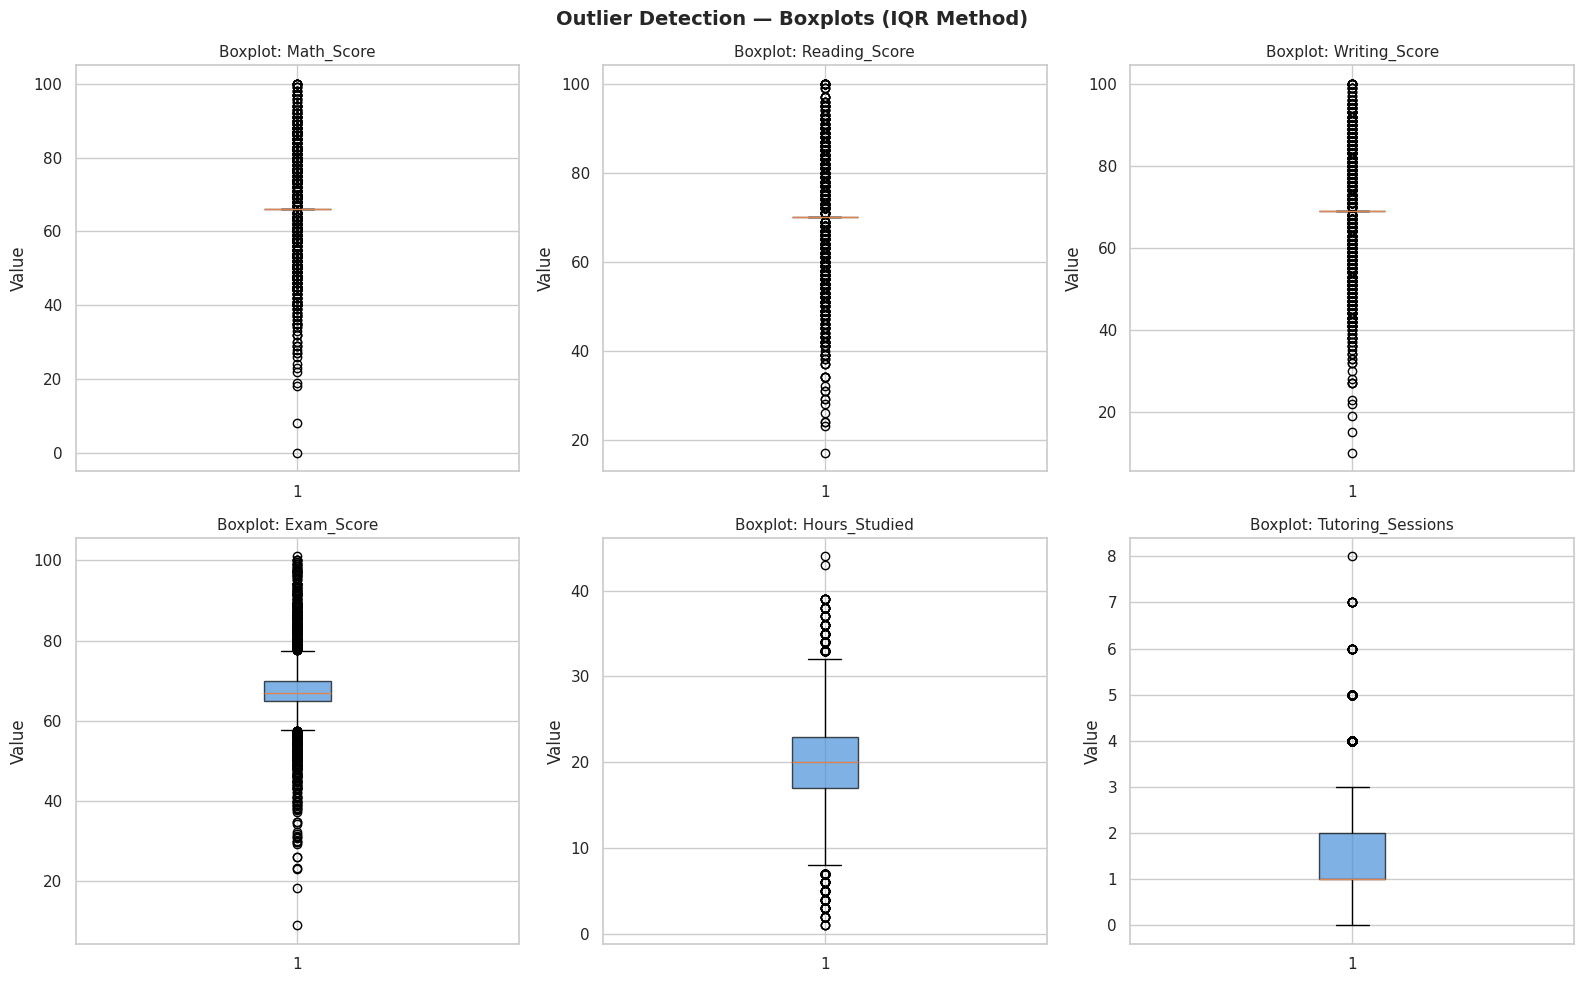


Outlier capping (Winsorization) complete.


In [7]:
print("=" * 60)
print("OUTLIER DETECTION")
print("=" * 60)

numerical_cols = merged_df.select_dtypes(include=[np.number]).columns.tolist()

"""Outlier Detection using IQR Method"""

print("Outlier Detection using IQR Method:\n")
outlier_summary = {}
for col in numerical_cols:
    Q1 = merged_df[col].quantile(0.25)
    Q3 = merged_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = merged_df[(merged_df[col] < lower) | (merged_df[col] > upper)]
    outlier_summary[col] = len(outliers)
    if len(outliers) > 0:
        print(f"  {col}: {len(outliers)} outliers (range: {lower:.1f} - {upper:.1f})")

"""Outlier Visualization (Boxplot)"""

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
plot_cols = [c for c in numerical_cols if outlier_summary.get(c, 0) > 0][:6]

for i, col in enumerate(plot_cols):
    axes[i].boxplot(merged_df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#4A90D9', alpha=0.7))
    axes[i].set_title(f'Boxplot: {col}', fontsize=11)
    axes[i].set_ylabel('Value')

for j in range(len(plot_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Outlier Detection — Boxplots (IQR Method)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

"""Outlier Capping (Winsorization)"""

merged_clean = merged_df.copy()
for col in numerical_cols:
    if col == 'Exam_Score':
        continue
    Q1 = merged_clean[col].quantile(0.25)
    Q3 = merged_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    merged_clean[col] = merged_clean[col].clip(lower=lower, upper=upper)

print("\nOutlier capping (Winsorization) complete.")

PART 7: Encoding Categorical Variables

In [8]:
print("=" * 60)
print("CATEGORICAL ENCODING")
print("=" * 60)

df_encoded = merged_clean.copy()

"""Label Encoding"""

le = LabelEncoder()
binary_cols = ['Gender', 'Internet_Access', 'Learning_Disabilities',
               'Extracurricular_Activities', 'Pass_Fail']
for col in binary_cols:
    if col in df_encoded.columns:
        df_encoded[col + '_Enc'] = le.fit_transform(df_encoded[col].astype(str))
        print(f"Label Encoded: '{col}' -> '{col}_Enc'  mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

"""One-Hot Encoding"""

ohe_cols = ['Parental_Education_Level', 'Motivation_Level', 'Family_Income',
            'Teacher_Quality', 'School_Type', 'Peer_Influence',
            'Access_to_Resources', 'Parental_Involvement', 'Distance_from_Home']
ohe_cols_present = [c for c in ohe_cols if c in df_encoded.columns]

df_encoded = pd.get_dummies(df_encoded, columns=ohe_cols_present, drop_first=True)
print(f"\nOne-Hot Encoding complete.")

"""Grade Label Encoding"""

grade_order = {'A': 4, 'B': 3, 'C': 2, 'D': 1, 'F': 0}
df_encoded['Grade_Enc'] = df_encoded['Grade'].map(grade_order)

print(f"\nTotal columns after encoding: {df_encoded.shape[1]}")
print(f"Final shape: {df_encoded.shape}")

CATEGORICAL ENCODING
Label Encoded: 'Gender' -> 'Gender_Enc'  mapping: {'Female': np.int64(0), 'Male': np.int64(1)}
Label Encoded: 'Internet_Access' -> 'Internet_Access_Enc'  mapping: {'No': np.int64(0), 'Yes': np.int64(1)}
Label Encoded: 'Learning_Disabilities' -> 'Learning_Disabilities_Enc'  mapping: {'No': np.int64(0), 'Yes': np.int64(1)}
Label Encoded: 'Extracurricular_Activities' -> 'Extracurricular_Activities_Enc'  mapping: {'No': np.int64(0), 'Yes': np.int64(1)}
Label Encoded: 'Pass_Fail' -> 'Pass_Fail_Enc'  mapping: {'Fail': np.int64(0), 'Pass': np.int64(1)}

One-Hot Encoding complete.

Total columns after encoding: 40
Final shape: (7607, 40)


PART 8: Exploratory Data Analysis (EDA)

EXPLORATORY DATA ANALYSIS (EDA)


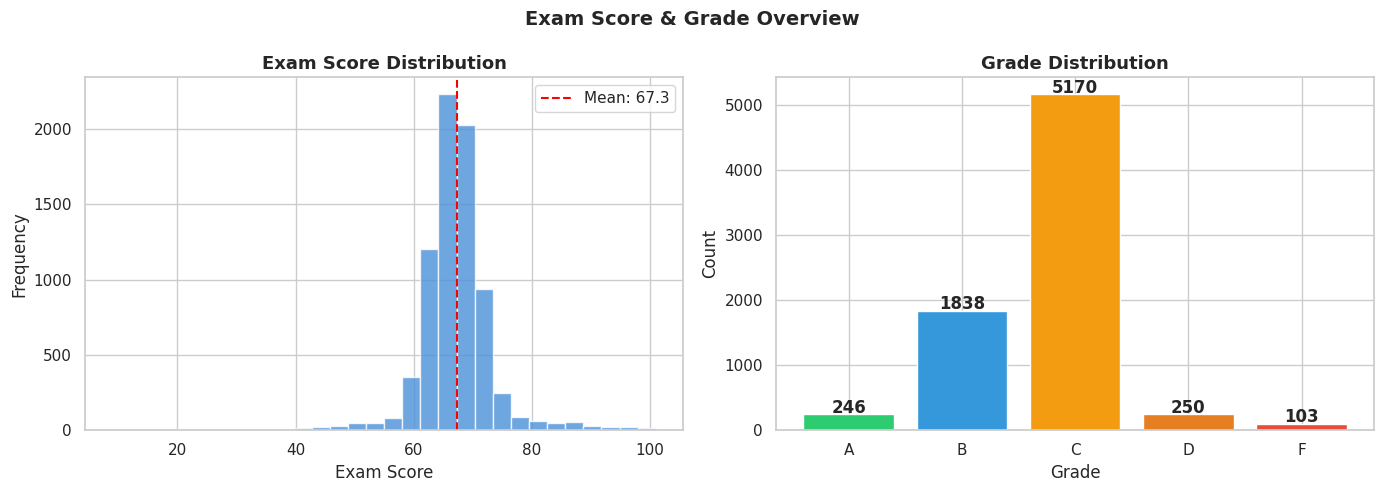

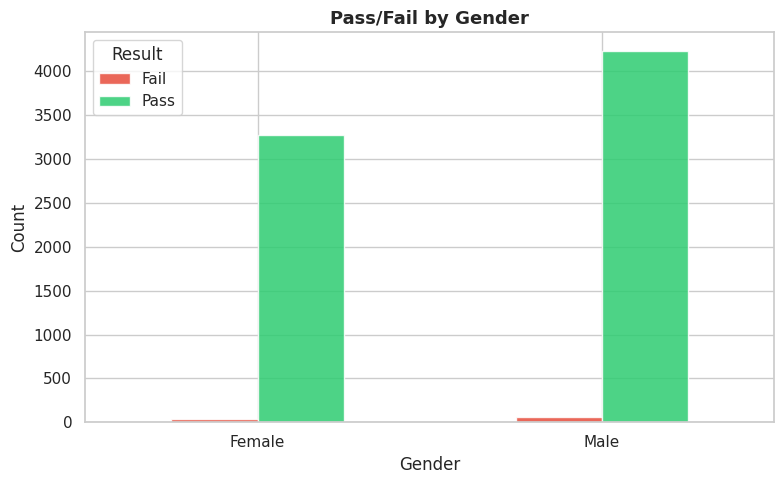

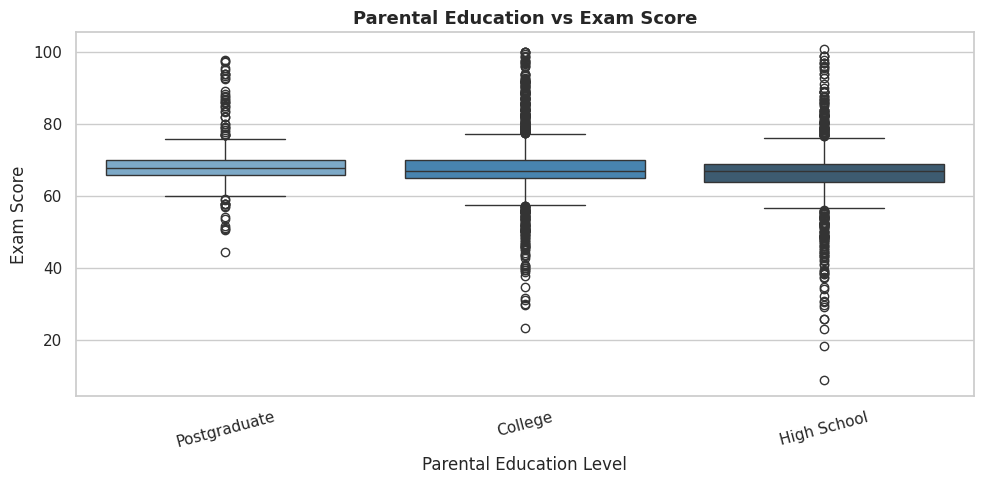

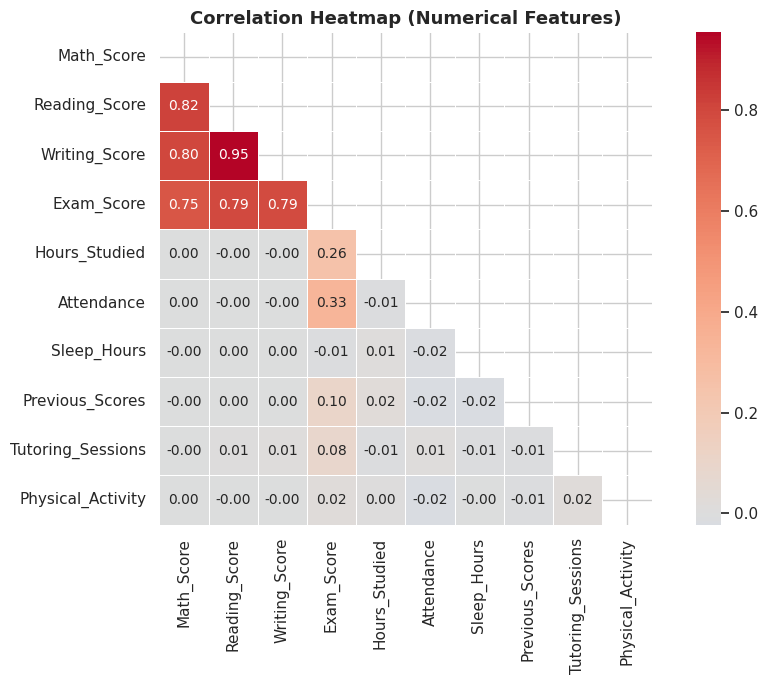


Grade Class Distribution (imbalance check):
Grade
C    5170
B    1838
D     250
A     246
F     103
Name: count, dtype: int64

Imbalance ratio (max/min): 50.19x


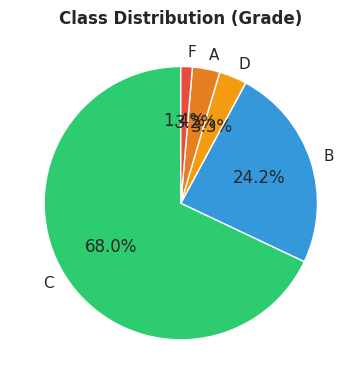

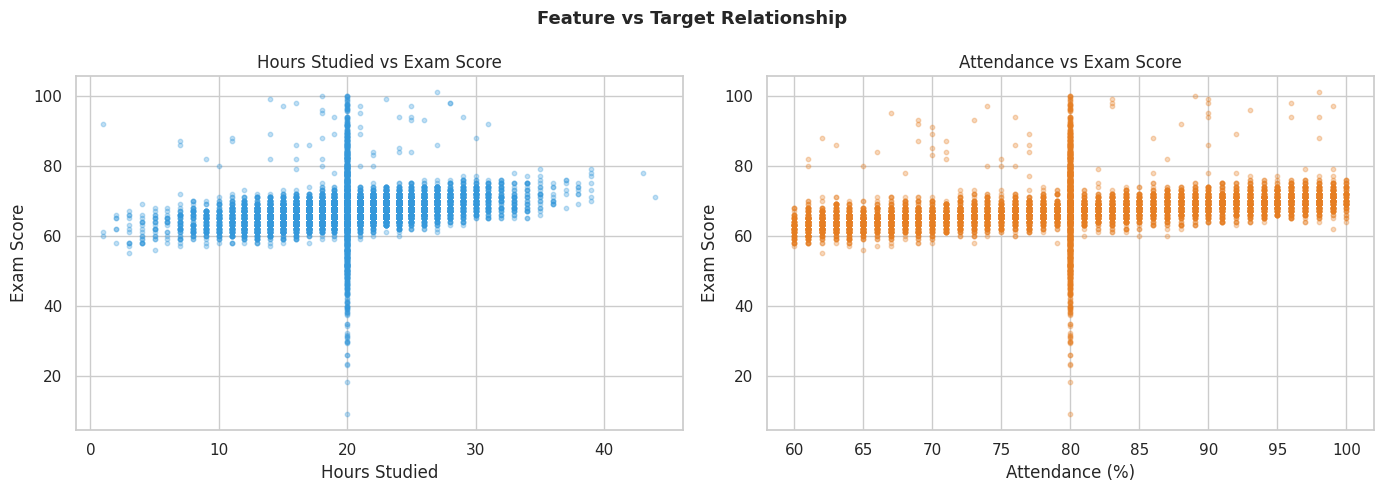

In [9]:
print("=" * 60)
print("EXPLORATORY DATA ANALYSIS (EDA)")
print("=" * 60)

"""Exam Score Distribution"""

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(merged_df['Exam_Score'], bins=30, color='#4A90D9', edgecolor='white', alpha=0.8)
axes[0].set_title('Exam Score Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Exam Score')
axes[0].set_ylabel('Frequency')
axes[0].axvline(merged_df['Exam_Score'].mean(), color='red', linestyle='--',
                label=f"Mean: {merged_df['Exam_Score'].mean():.1f}")
axes[0].legend()

grade_counts = merged_df['Grade'].value_counts().reindex(['A','B','C','D','F'])
colors = ['#2ecc71','#3498db','#f39c12','#e67e22','#e74c3c']
axes[1].bar(grade_counts.index, grade_counts.values, color=colors, edgecolor='white')
axes[1].set_title('Grade Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Grade')
axes[1].set_ylabel('Count')
for i, (g, v) in enumerate(zip(grade_counts.index, grade_counts.values)):
    axes[1].text(i, v + 20, str(v), ha='center', fontweight='bold')

plt.suptitle('Exam Score & Grade Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

"""Pass/Fail by Gender"""

plt.figure(figsize=(8, 5))
pf_gender = merged_df.groupby(['Gender', 'Pass_Fail']).size().unstack(fill_value=0)
pf_gender.plot(kind='bar', ax=plt.gca(), color=['#e74c3c', '#2ecc71'], edgecolor='white', alpha=0.85)
plt.title('Pass/Fail by Gender', fontsize=13, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Result')
plt.tight_layout()
plt.show()

"""Parental Education vs Exam Score"""

plt.figure(figsize=(10, 5))
order = merged_df.groupby('Parental_Education_Level')['Exam_Score'].median().sort_values(ascending=False).index
sns.boxplot(data=merged_df, x='Parental_Education_Level', y='Exam_Score',
            order=order, palette='Blues_d')
plt.title('Parental Education vs Exam Score', fontsize=13, fontweight='bold')
plt.xlabel('Parental Education Level')
plt.ylabel('Exam Score')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

"""Correlation Heatmap"""

num_df = merged_df[numerical_cols].copy()
corr_matrix = num_df.corr()

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, center=0, linewidths=0.5, square=True,
            annot_kws={'size': 10})
plt.title('Correlation Heatmap (Numerical Features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

"""Class Imbalance Check"""

print("\nGrade Class Distribution (imbalance check):")
grade_dist = merged_df['Grade'].value_counts()
print(grade_dist)
print(f"\nImbalance ratio (max/min): {grade_dist.max() / grade_dist.min():.2f}x")

plt.figure(figsize=(6, 4))
grade_dist.plot(kind='pie', autopct='%1.1f%%',
                colors=['#2ecc71','#3498db','#f39c12','#e67e22','#e74c3c'],
                startangle=90)
plt.title('Class Distribution (Grade)', fontsize=12, fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.show()

"""Hours Studied & Attendance vs Exam Score"""

if 'Hours_Studied' in merged_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].scatter(merged_df['Hours_Studied'], merged_df['Exam_Score'],
                    alpha=0.3, color='#3498db', s=10)
    axes[0].set_title('Hours Studied vs Exam Score')
    axes[0].set_xlabel('Hours Studied')
    axes[0].set_ylabel('Exam Score')

    axes[1].scatter(merged_df['Attendance'], merged_df['Exam_Score'],
                    alpha=0.3, color='#e67e22', s=10)
    axes[1].set_title('Attendance vs Exam Score')
    axes[1].set_xlabel('Attendance (%)')
    axes[1].set_ylabel('Exam Score')

    plt.suptitle('Feature vs Target Relationship', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

PART 9: Feature Preparation for Modeling

In [10]:
print("=" * 60)
print("FEATURE PREPARATION")
print("=" * 60)

"""Separating Target and Features"""

TARGET = 'Grade_Enc'

drop_cols = ['Grade', 'Pass_Fail', 'Pass_Fail_Enc', 'Source_Dataset',
             'Exam_Score', 'Math_Score', 'Reading_Score', 'Writing_Score',
             'Gender', 'Race_Ethnicity', 'Lunch', 'Test_Prep_Course',
             'Parental_Education_Level']
drop_cols_present = [c for c in drop_cols if c in df_encoded.columns]

X = df_encoded.drop(columns=drop_cols_present + [TARGET])
y = df_encoded[TARGET]

"""Converting Boolean Columns to int"""

bool_cols = X.select_dtypes(include=['bool']).columns
X[bool_cols] = X[bool_cols].astype(int)

"""Dropping Remaining Object Columns"""

obj_cols = X.select_dtypes(include=['object']).columns.tolist()
if obj_cols:
    X.drop(columns=obj_cols, inplace=True)
    print(f"Object columns removed: {obj_cols}")

"""NaN Check and Fill"""

X.fillna(X.median(numeric_only=True), inplace=True)

print(f"Feature matrix X shape: {X.shape}")
print(f"Target y shape: {y.shape}")
print(f"Feature names: {X.columns.tolist()}")

"""Train-Test Split"""

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")

"""Feature Scaling (StandardScaler)"""

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("Scaling with StandardScaler complete.")

FEATURE PREPARATION
Object columns removed: ['Extracurricular_Activities', 'Internet_Access', 'Learning_Disabilities']
Feature matrix X shape: (7607, 27)
Target y shape: (7607,)
Feature names: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Gender_Enc', 'Internet_Access_Enc', 'Learning_Disabilities_Enc', 'Extracurricular_Activities_Enc', 'Parental_Education_Level_High School', 'Parental_Education_Level_Postgraduate', 'Motivation_Level_Low', 'Motivation_Level_Medium', 'Family_Income_Low', 'Family_Income_Medium', 'Teacher_Quality_Low', 'Teacher_Quality_Medium', 'School_Type_Public', 'Peer_Influence_Neutral', 'Peer_Influence_Positive', 'Access_to_Resources_Low', 'Access_to_Resources_Medium', 'Parental_Involvement_Low', 'Parental_Involvement_Medium', 'Distance_from_Home_Moderate', 'Distance_from_Home_Near']

Train size: 6085  |  Test size: 1522
Scaling with StandardScaler complete.


PART 10: Model Training & Evaluation

In [11]:
print("=" * 60)
print("MODEL TRAINING & EVALUATION")
print("=" * 60)

"""Models Dictionary (5 Models)"""

models = {
    '1. Logistic Regression':  LogisticRegression(max_iter=1000, random_state=42),
    '2. Decision Tree':        DecisionTreeClassifier(max_depth=10, random_state=42),
    '3. Random Forest':        RandomForestClassifier(n_estimators=100, random_state=42),
    '4. KNN':                  KNeighborsClassifier(n_neighbors=5),
    '5. Neural Network (MLP)': MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300,
                                             random_state=42)
}

# Models that require scaled data
scaled_models = ['1. Logistic Regression', '4. KNN', '5. Neural Network (MLP)']

"""Model Training Loop"""

results = {}
cv_results = {}
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    print(f"\nTraining: {name} ...")

    needs_scaling = name in scaled_models
    X_tr = X_train_scaled if needs_scaling else X_train
    X_te = X_test_scaled  if needs_scaling else X_test

    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    cv_scores = cross_val_score(model, X_tr, y_train, cv=kfold,
                                scoring='accuracy', n_jobs=-1)

    results[name] = {
        'Accuracy':  round(acc, 4),
        'Precision': round(prec, 4),
        'Recall':    round(rec, 4),
        'F1-Score':  round(f1, 4),
        'CV Mean':   round(cv_scores.mean(), 4),
        'CV Std':    round(cv_scores.std(), 4)
    }
    cv_results[name] = cv_scores

    print(f"   Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
    print(f"   CV Accuracy: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

MODEL TRAINING & EVALUATION

Training: 1. Logistic Regression ...
   Accuracy: 0.8344 | Precision: 0.7813 | Recall: 0.8344 | F1: 0.8015
   CV Accuracy: 0.8491 +/- 0.0061

Training: 2. Decision Tree ...
   Accuracy: 0.7700 | Precision: 0.7418 | Recall: 0.7700 | F1: 0.7506
   CV Accuracy: 0.7619 +/- 0.0092

Training: 3. Random Forest ...
   Accuracy: 0.8114 | Precision: 0.7926 | Recall: 0.8114 | F1: 0.7812
   CV Accuracy: 0.8130 +/- 0.0079

Training: 4. KNN ...
   Accuracy: 0.7378 | Precision: 0.7050 | Recall: 0.7378 | F1: 0.7000
   CV Accuracy: 0.7392 +/- 0.0129

Training: 5. Neural Network (MLP) ...
   Accuracy: 0.8647 | Precision: 0.8389 | Recall: 0.8647 | F1: 0.8420
   CV Accuracy: 0.8610 +/- 0.0136


PART 11: Model Comparison

MODEL COMPARISON TABLE

Model Performance Summary:


,Accuracy,Precision,Recall,F1-Score,CV Mean,CV Std
Neural Network (MLP),0.8647,0.8389,0.8647,0.8420,0.8610,0.0136
Logistic Regression,0.8344,0.7813,0.8344,0.8015,0.8491,0.0061
Random Forest,0.8114,0.7926,0.8114,0.7812,0.8130,0.0079
Decision Tree,0.7700,0.7418,0.7700,0.7506,0.7619,0.0092
KNN,0.7378,0.7050,0.7378,0.7000,0.7392,0.0129


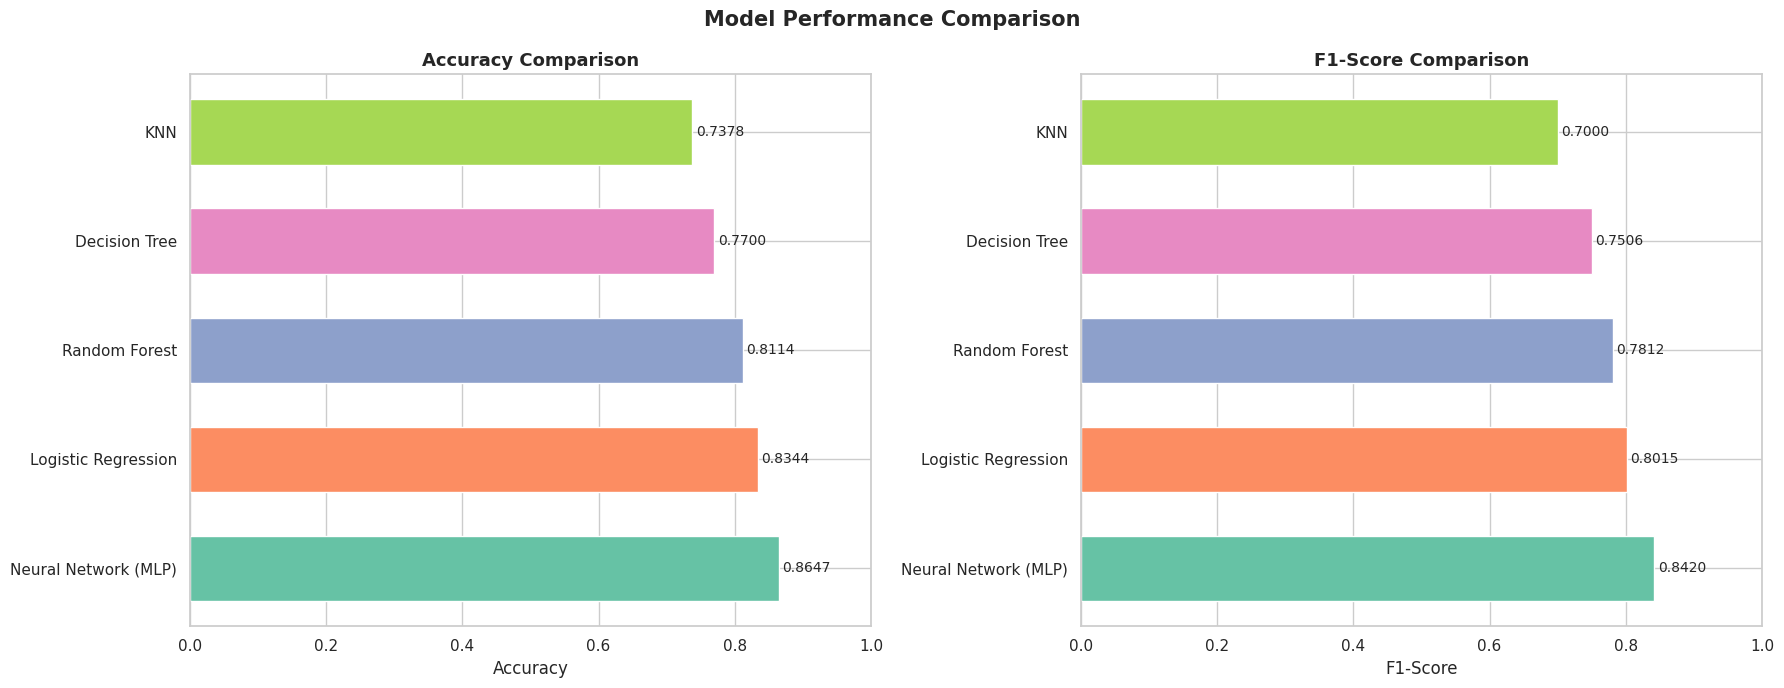

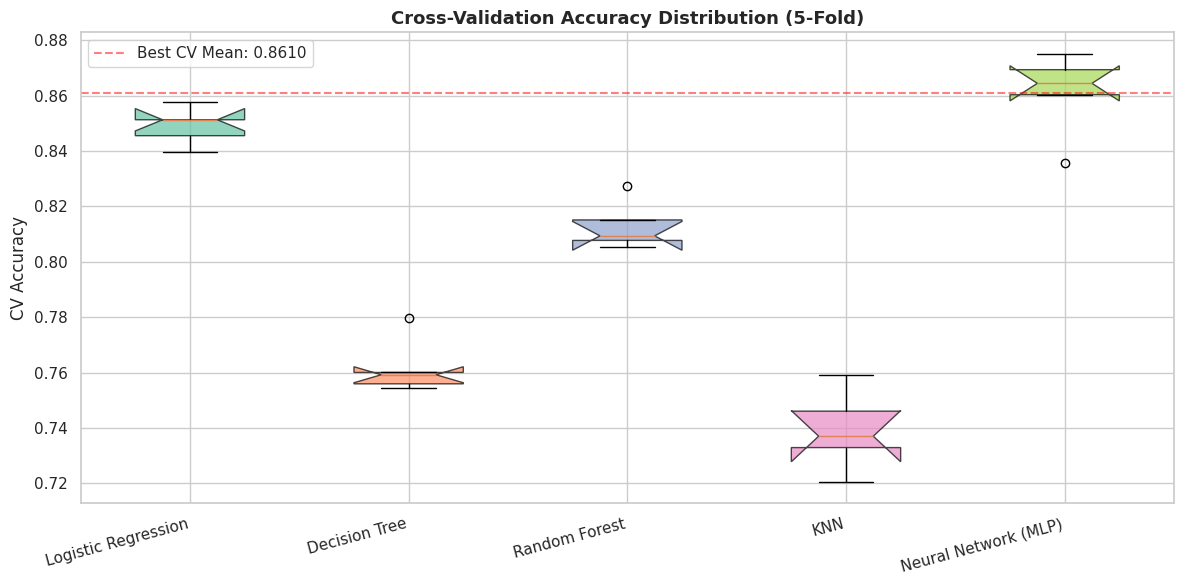

In [12]:
print("=" * 60)
print("MODEL COMPARISON TABLE")
print("=" * 60)

results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('F1-Score', ascending=False)
results_df.index = [i.split('. ')[1] for i in results_df.index]

print("\nModel Performance Summary:")
display(results_df.style
        .highlight_max(subset=['Accuracy','Precision','Recall','F1-Score','CV Mean'],
                       color='#90EE90')
        .highlight_min(subset=['Accuracy','Precision','Recall','F1-Score','CV Mean'],
                       color='#FFB6C1')
        .format("{:.4f}"))

"""Bar Chart Comparison"""

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

metrics     = ['Accuracy', 'F1-Score']
colors_list = plt.cm.Set2.colors

for idx, metric in enumerate(metrics):
    vals   = results_df[metric].values
    labels = results_df.index.tolist()
    bars   = axes[idx].barh(labels, vals, color=colors_list[:len(labels)],
                             edgecolor='white', height=0.6)
    axes[idx].set_xlim(0, 1.0)
    axes[idx].set_title(f'{metric} Comparison', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel(metric)
    for bar, val in zip(bars, vals):
        axes[idx].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                       f'{val:.4f}', va='center', fontsize=10)

plt.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

"""Cross-Validation Box Plot"""

plt.figure(figsize=(12, 6))
cv_data   = [cv_results[k] for k in models.keys()]
cv_labels = [k.split('. ')[1] for k in models.keys()]
bp = plt.boxplot(cv_data, labels=cv_labels, patch_artist=True, notch=True)
for patch, color in zip(bp['boxes'], colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
plt.title('Cross-Validation Accuracy Distribution (5-Fold)', fontsize=13, fontweight='bold')
plt.ylabel('CV Accuracy')
plt.xticks(rotation=15, ha='right')
plt.axhline(y=results_df['CV Mean'].max(), color='red', linestyle='--', alpha=0.5,
            label=f"Best CV Mean: {results_df['CV Mean'].max():.4f}")
plt.legend()
plt.tight_layout()
plt.show()

PART 12: Confusion Matrix (Top 3 Models)

CONFUSION MATRICES — TOP 3 MODELS


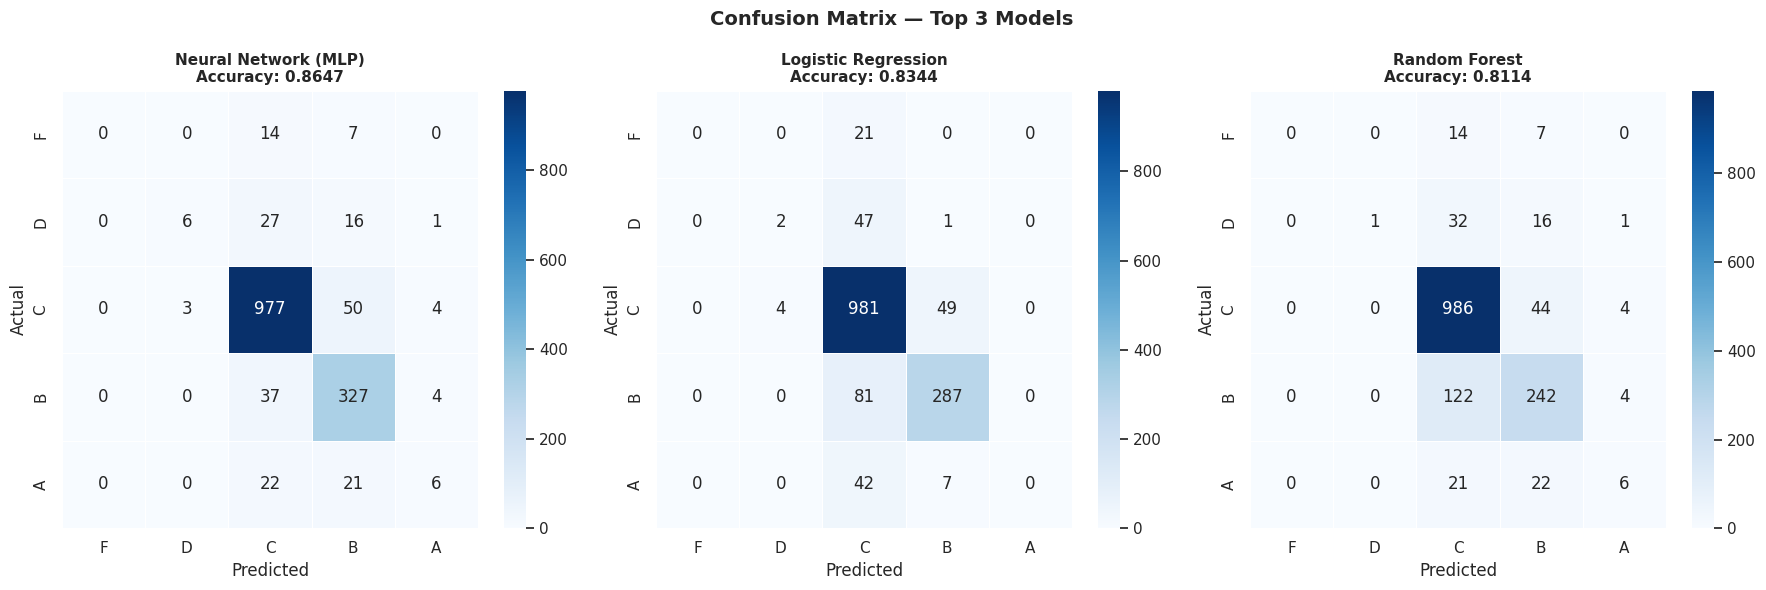


Classification Report — Best Model: Neural Network (MLP)
              precision    recall  f1-score   support

           F       0.00      0.00      0.00        21
           D       0.67      0.12      0.20        50
           C       0.91      0.94      0.93      1034
           B       0.78      0.89      0.83       368
           A       0.40      0.12      0.19        49

    accuracy                           0.86      1522
   macro avg       0.55      0.42      0.43      1522
weighted avg       0.84      0.86      0.84      1522



In [13]:
print("=" * 60)
print("CONFUSION MATRICES — TOP 3 MODELS")
print("=" * 60)

top3_names   = results_df.head(3).index.tolist()
grade_labels = ['F', 'D', 'C', 'B', 'A']

short_to_full = {k.split('. ')[1]: k for k in models.keys()}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, short_name in enumerate(top3_names):
    full_name   = short_to_full[short_name]
    model       = models[full_name]
    needs_scale = full_name in ['1. Logistic Regression', '4. KNN', '5. Neural Network (MLP)']
    X_te        = X_test_scaled if needs_scale else X_test
    y_pred      = model.predict(X_te)

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=grade_labels, yticklabels=grade_labels,
                linewidths=0.5)
    acc = accuracy_score(y_test, y_pred)
    axes[idx].set_title(f'{short_name}\nAccuracy: {acc:.4f}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.suptitle('Confusion Matrix — Top 3 Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

"""Classification Report (Best Model)"""

best_name_short = results_df.index[0]
best_name_full  = short_to_full[best_name_short]
best_model      = models[best_name_full]
needs_scale     = best_name_full in ['1. Logistic Regression', '4. KNN', '5. Neural Network (MLP)']
X_te_best       = X_test_scaled if needs_scale else X_test
y_pred_best     = best_model.predict(X_te_best)

print(f"\nClassification Report — Best Model: {best_name_short}")
print(classification_report(y_test, y_pred_best,
                             target_names=grade_labels, zero_division=0))

PART 13: ROC-AUC Curve (Best Model)

ROC-AUC CURVE — BEST MODEL


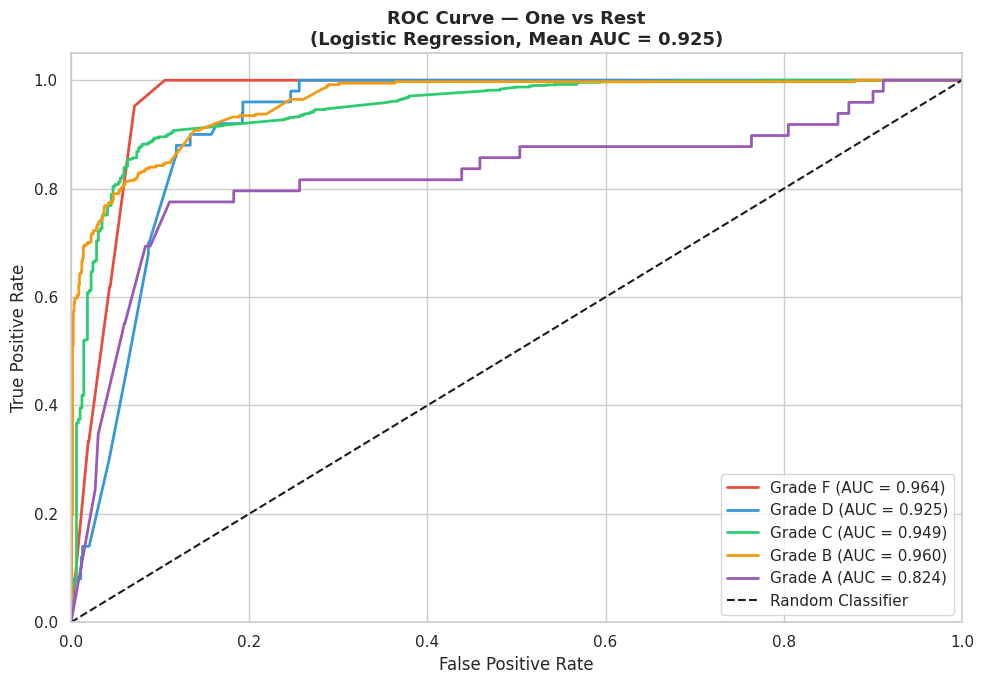


Mean AUC Score: 0.9246


In [14]:
print("=" * 60)
print("ROC-AUC CURVE — BEST MODEL")
print("=" * 60)

from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from itertools import cycle

n_classes  = len(np.unique(y))
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

"""Retraining Best Model with OneVsRest"""

best_model_ovr = OneVsRestClassifier(
    LogisticRegression(max_iter=1000, random_state=42)
)
best_model_ovr.fit(X_train_scaled, y_train)
y_score = best_model_ovr.predict_proba(X_test_scaled)

plt.figure(figsize=(10, 7))
colors_roc = cycle(['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6'])
auc_scores = []

for i, (color, label) in enumerate(zip(colors_roc, grade_labels)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    auc_val      = roc_auc_score(y_test_bin[:, i], y_score[:, i])
    auc_scores.append(auc_val)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'Grade {label} (AUC = {auc_val:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title(f'ROC Curve — One vs Rest\n(Logistic Regression, Mean AUC = {np.mean(auc_scores):.3f})',
          fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"\nMean AUC Score: {np.mean(auc_scores):.4f}")

PART 14: Feature Importance (Random Forest)

FEATURE IMPORTANCE — Random Forest


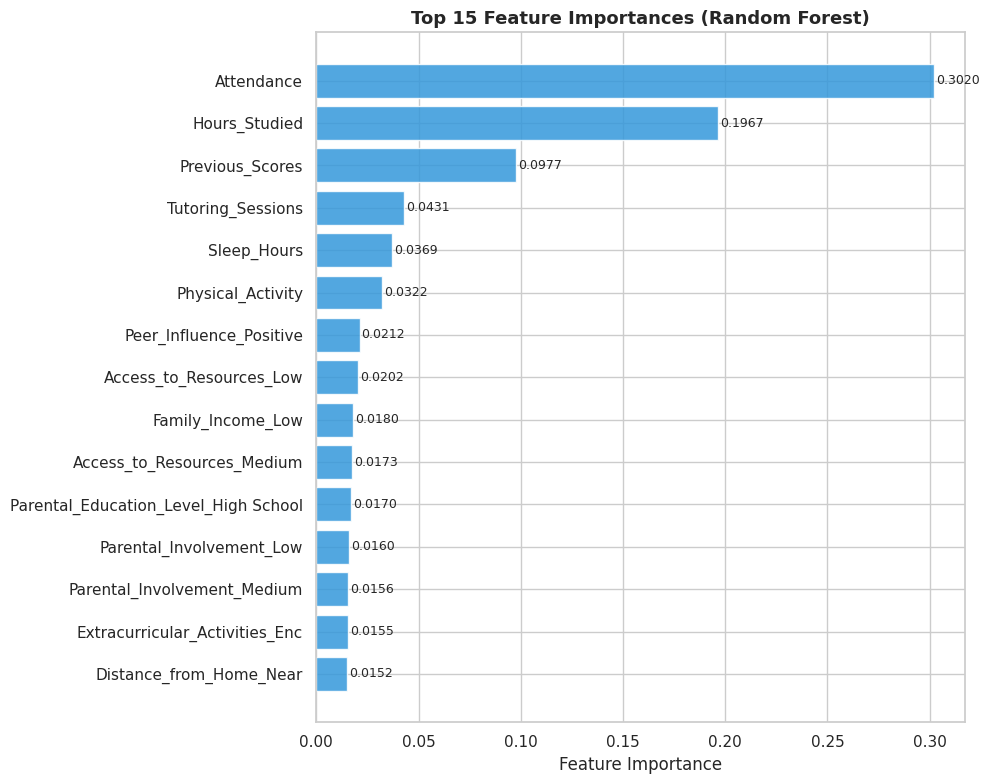


Top 10 Most Important Features:


,Feature,Importance
0,Attendance,0.302034
1,Hours_Studied,0.196682
2,Previous_Scores,0.097726
3,Tutoring_Sessions,0.043060
4,Sleep_Hours,0.036930
5,Physical_Activity,0.032205
6,Peer_Influence_Positive,0.021156
7,Access_to_Resources_Low,0.020218
8,Family_Income_Low,0.018017
9,Access_to_Resources_Medium,0.017291


In [15]:
print("=" * 60)
print("FEATURE IMPORTANCE — Random Forest")
print("=" * 60)

rf_model    = models['3. Random Forest']
importances = rf_model.feature_importances_
feat_names  = X.columns.tolist()

feat_imp_df = pd.DataFrame({
    'Feature':    feat_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 8))
bars = plt.barh(feat_imp_df['Feature'][::-1],
                feat_imp_df['Importance'][::-1],
                color='#3498db', edgecolor='white', alpha=0.85)
plt.xlabel('Feature Importance', fontsize=12)
plt.title('Top 15 Feature Importances (Random Forest)', fontsize=13, fontweight='bold')
for bar, val in zip(bars, feat_imp_df['Importance'][::-1]):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features:")
display(feat_imp_df.head(10).reset_index(drop=True))

PART 15: Final Summary

In [16]:
print("\n")
print("=" * 60)
print("FINAL PROJECT SUMMARY")
print("=" * 60)

print(f"\nDataset Overview:")
print(f"   DS1 (StudentsPerformance): 1,000 rows, 8 features")
print(f"   DS2 (StudentPerformanceFactors): {len(df2_clean)} rows, 20 features")
print(f"   Merged Dataset: {len(merged_df)} rows")

print(f"\nTarget: Grade Classification (A / B / C / D / F)")
print(f"   A (>=80)  |  B (70-79)  |  C (60-69)  |  D (50-59)  |  F (<50)")

print(f"\nGrade Distribution:")
for grade, count in merged_df['Grade'].value_counts().reindex(['A','B','C','D','F']).items():
    pct = count / len(merged_df) * 100
    print(f"   Grade {grade}: {count} ({pct:.1f}%)")

print(f"\nModel Comparison (sorted by F1-Score):")
display(results_df[['Accuracy', 'F1-Score', 'CV Mean']].style.format("{:.4f}")
        .highlight_max(color='#90EE90'))

best = results_df.index[0]
print(f"\nBEST MODEL: {best}")
print(f"   Accuracy:  {results_df.loc[best, 'Accuracy']:.4f}")
print(f"   F1-Score:  {results_df.loc[best, 'F1-Score']:.4f}")
print(f"   CV Mean:   {results_df.loc[best, 'CV Mean']:.4f}")
print(f"   CV Std:    {results_df.loc[best, 'CV Std']:.4f}")

top_feat = feat_imp_df.iloc[0]['Feature']
print(f"\nTop Feature: '{top_feat}' — Most influential factor on Exam Score")
print("\nFull Pipeline Complete!")



FINAL PROJECT SUMMARY

Dataset Overview:
   DS1 (StudentsPerformance): 1,000 rows, 8 features
   DS2 (StudentPerformanceFactors): 6607 rows, 20 features
   Merged Dataset: 7607 rows

Target: Grade Classification (A / B / C / D / F)
   A (>=80)  |  B (70-79)  |  C (60-69)  |  D (50-59)  |  F (<50)

Grade Distribution:
   Grade A: 246 (3.2%)
   Grade B: 1838 (24.2%)
   Grade C: 5170 (68.0%)
   Grade D: 250 (3.3%)
   Grade F: 103 (1.4%)

Model Comparison (sorted by F1-Score):


,Accuracy,F1-Score,CV Mean
Neural Network (MLP),0.8647,0.8420,0.8610
Logistic Regression,0.8344,0.8015,0.8491
Random Forest,0.8114,0.7812,0.8130
Decision Tree,0.7700,0.7506,0.7619
KNN,0.7378,0.7000,0.7392



BEST MODEL: Neural Network (MLP)
   Accuracy:  0.8647
   F1-Score:  0.8420
   CV Mean:   0.8610
   CV Std:    0.0136

Top Feature: 'Attendance' — Most influential factor on Exam Score

Full Pipeline Complete!
